In [154]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

## Question 1: How does IMDb rating correlate with the number of votes and gross earnings?

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
C:\Users\ryanp\AppData\Local\Temp\ipykernel_71412\1576808151.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['Gross'] = df['Gross'].replace({'\$': '', ',': ''}, regex=True).astype(float)


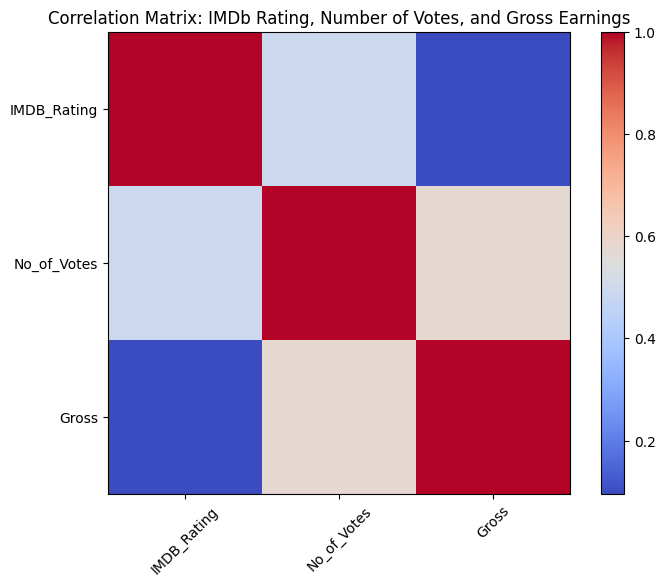

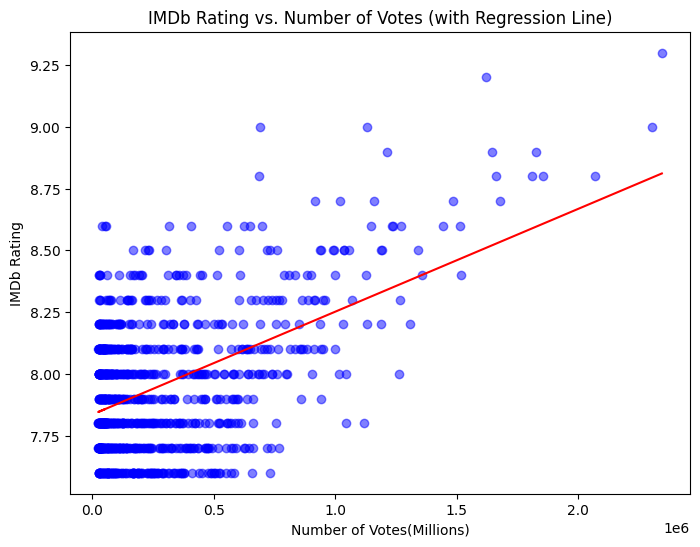

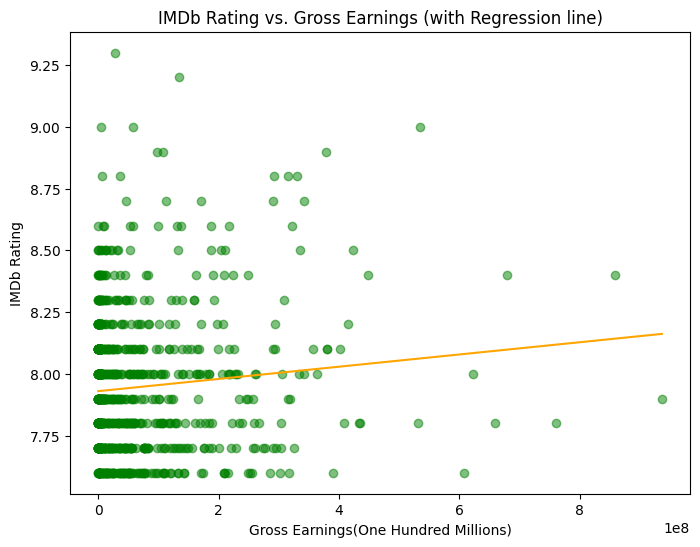

In [155]:
# Load the dataset (assuming it's a CSV file)
df = pd.read_csv('imdb_top_1000.csv')  # Adjust path as necessary

# Clean data (remove commas, handle missing values)
df['Gross'] = df['Gross'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df['No_of_Votes'] = pd.to_numeric(df['No_of_Votes'], errors='coerce')

# Correlation Matrix Heatmap
correlation_matrix = df[['IMDB_Rating', 'No_of_Votes', 'Gross']].corr()
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix: IMDb Rating, Number of Votes, and Gross Earnings')
plt.show()

# Scatterplot: IMDb Rating vs. Number of Votes (with regression line)
plt.figure(figsize=(8, 6))
plt.scatter(df['No_of_Votes'], df['IMDB_Rating'], color='blue', alpha=0.5)

# Calculate regression line using scipy.stats.linregress
slope, intercept, _, _, _ = stats.linregress(df['No_of_Votes'], df['IMDB_Rating'])
plt.plot(df['No_of_Votes'], slope * df['No_of_Votes'] + intercept, color='red')

plt.title('IMDb Rating vs. Number of Votes (with Regression Line)')
plt.xlabel('Number of Votes(Millions)')
plt.ylabel('IMDb Rating')
plt.show()



# Drop rows with missing values in Gross or IMDb_Rating
valid_data = df[['Gross', 'IMDB_Rating']].dropna()

# Scatterplot: IMDb Rating vs. Gross Earnings
plt.figure(figsize=(8, 6))
plt.scatter(valid_data['Gross'], valid_data['IMDB_Rating'], color='green', alpha=0.5)

# Calculate regression line using scipy.stats.linregress
from scipy import stats
slope, intercept, _, _, _ = stats.linregress(valid_data['Gross'], valid_data['IMDB_Rating'])

# Sort values for a proper regression line
sorted_gross = valid_data['Gross'].sort_values()
plt.plot(sorted_gross, slope * sorted_gross + intercept, color='orange')

plt.title('IMDb Rating vs. Gross Earnings (with Regression line)')
plt.xlabel('Gross Earnings(One Hundred Millions)')
plt.ylabel('IMDb Rating')
plt.show()

In [156]:
## Interpretation:
# Correlation Matrix: 
# The light blue color indicates a moderate positive correlation. This means that movies with more votes tend to have slightly higher IMDb ratings, suggesting popularity can somewhat reflect higher audience approval. 
# IMDb Rating vs. Gross Earnings: The dark blue color here indicates a weak or low correlation.
# Higher gross earnings don’t strongly associate with higher IMDb ratings—financial success doesn’t always align with critical acclaim.
# Number of Votes vs. Gross Earnings: This relationship is moderately positive (light beige color), suggesting that more popular movies (with more votes) tend to earn more, which makes sense commercially.

# Graph 1- IMDb Rating vs. Number of Votes (Regression Line)
# Obeservations:
# There is a clear upward trend in the red regression line.
# As the number of votes increases, IMDb ratings tend to slightly increase.
# Although the scatter is widespread at lower vote counts, higher-vote movies tend to stay above 8.0 in rating.
# Interpretation:
# Movies that engage a large audience (hence more votes) generally receive better ratings.
# This could be due to increased exposure or cult followings for well-received films.

# Graph 2- IMDb Rating vs. Gross Earnings (Regression Line)

# Observations:
# The orange regression line has a very gentle positive slope.
# The plot is highly scattered, especially at lower earnings.
# A few movies with massive earnings have various IMDb ratings, both high and average.
# Interpretation:
# There is a weak positive relationship between gross earnings and IMDb rating.
# High-grossing films can still have moderate ratings, likely due to marketing power, star power, or franchise recognition rather than critical quality.


## 2. Can we classify movies based on IMDb ratings using k-Nearest Neighbors (k-NN)?

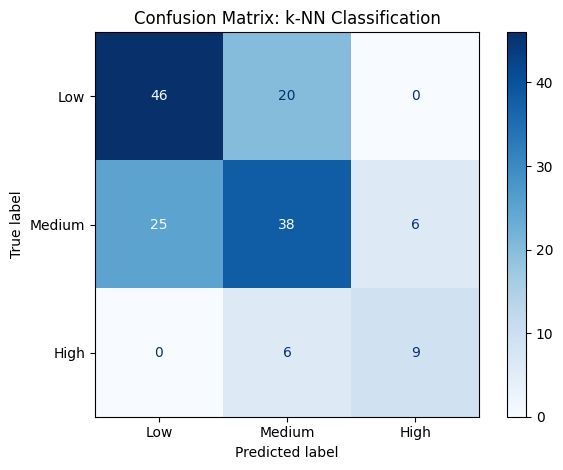

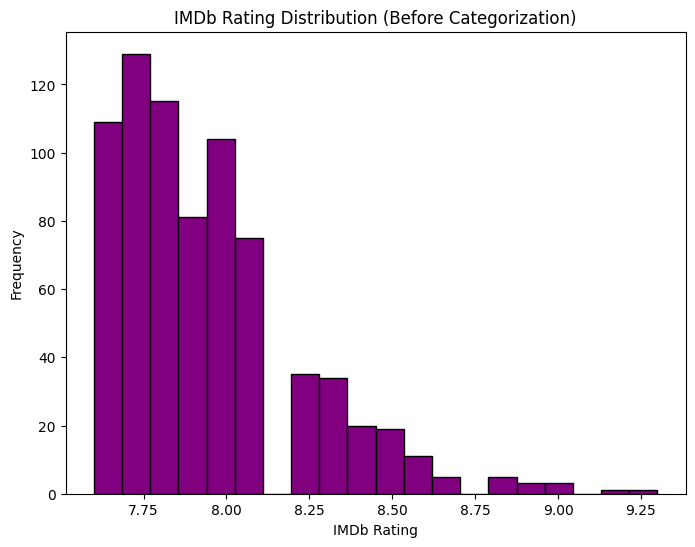

In [157]:
# Clean runtime and meta score for features
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False).astype(float)
df = df.dropna(subset=['Runtime', 'Meta_score', 'Gross'])

# Create rating categories
def categorize_rating(rating):
    if rating < 7.9:
        return 'Low'
    elif rating < 8.4:
        return 'Medium'
    else: 
        return 'High'

df['Rating_Class'] = df['IMDB_Rating'].apply(categorize_rating)

# Features and target
features = df[['Runtime', 'Meta_score', 'No_of_Votes', 'Gross']]
target = df['Rating_Class']

# Normalize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])

# Plot
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: k-NN Classification")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df['IMDB_Rating'], bins=20, color='purple', edgecolor='black')
plt.title('IMDb Rating Distribution (Before Categorization)')
plt.xlabel('IMDb Rating')
plt.ylabel('Frequency')
plt.show()

In [158]:
# Interpretation:
# Confusion Matrix:
# The confusion matrix shows predicted vs. actual class labels (Low, Medium, High).
# The model never predicted or encountered the “Low” class — this makes sense as it the top 1000 movies from IMDB 
#Correctly classified 97 as “Medium”
# 11 misclassified as “High”
# True High:
#28 correctly predicted as “High”
# 14 misclassified as “Medium”
# True Low: 0 (none predicted or present in test set)
# Takeaways:
# The classifier performs reasonably well, especially for “Medium” ratings.

# Bar Chart:IMDb Rating Distribution
# Most IMDb ratings fall between 7.6 to 8.2.
# Skewed slightly left (negatively skewed) — fewer movies with very high ratings.
# Very few ratings above 9.0 or below 7.5.
# Shows why the "Low class" is under-representes; because it's not there
# The ratings are not uniformly distributed, making classification more challenging.


## Question 3: How does a movie’s runtime impact its gross earnings?

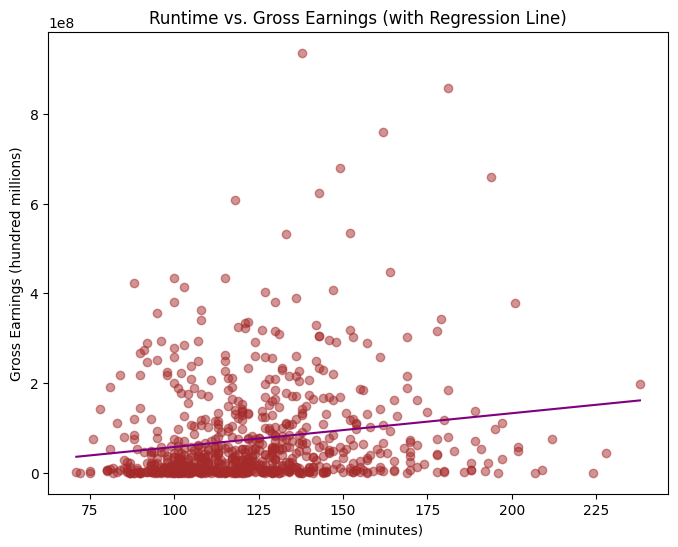

In [159]:
# Clean runtime data
df['Runtime'] = df['Runtime'].replace({' min': ''}, regex=True).astype(float)

# Drop rows with missing values in Runtime or Gross
valid_data = df[['Runtime', 'Gross']].dropna()

# Scatterplot: Runtime vs. Gross Earnings
plt.figure(figsize=(8, 6))
plt.scatter(valid_data['Runtime'], valid_data['Gross'], color='brown', alpha=0.5)

# Calculate regression line using scipy.stats.linregress
from scipy import stats
slope, intercept, _, _, _ = stats.linregress(valid_data['Runtime'], valid_data['Gross'])

# Sort x-values for smooth regression line
sorted_runtime = valid_data['Runtime'].sort_values()
plt.plot(sorted_runtime, slope * sorted_runtime + intercept, color='purple')

plt.title('Runtime vs. Gross Earnings (with Regression Line)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Gross Earnings (hundred millions)')
plt.show()

In [160]:
#Interpretation: Runtime vs. Gross Earnings with Regression Line
# Scatterplot shows no strong linear relationship between runtime and gross earnings.
# A slight upward trend is present (as shown by the regression line), but with a lot of variance.
# Several outliers earn extremely high despite varied runtimes.
# Runtime ranges mainly between 80 and 150 minutes.
# Runtime has a weak positive correlation with gross earnings — longer movies might earn more, but not significantly.
# Other factors (genre, budget, marketing, star cast) likely play a bigger role in earnings.
# The large spread suggests high variability and possible non-linear relationships.